In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!mkdir -p /content/computer_vision
!find "/content/drive/Shareddrives/Computer Vision/generation_output" -mindepth 1 -maxdepth 1 -exec cp -r -t /content/computer_vision/ {} +


In [ ]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import json
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# --- CONFIGURATION ---
MODEL_PATH = '/content/drive/Shareddrives/Computer Vision/faces_model_checkpoints/resnet34_faces_best_32.pt'
LABEL_MAP_PATH = '/content/drive/Shareddrives/Computer Vision/faces_model_checkpoints/label_map.json'
TEST_DIR = '/content/computer_vision'

# Parameters
IMG_SIZE = 32
NUM_CLASSES = 10
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Configuration set. Using device: {DEVICE}")


Configuration set. Using device: cuda


In [ ]:
# --- HELPER FUNCTIONS ---

def load_label_map(path):
    """Reads the JSON label map and converts keys to integers."""
    if not os.path.exists(path):
        print(f"Error: Label map not found at {path}")
        return {}
    with open(path, 'r') as f:
        mapping = json.load(f)
    return {int(k): v for k, v in mapping.items()}

def get_model(model_path, num_classes, device):
    """Loads model architecture and weights."""
    print(f"Loading model from: {model_path}")

    # 注意：你的檔名寫 resnet18，但原本程式碼是用 resnet34。
    # 這裡保留你原本的 resnet34 設定，如果報錯請改回 resnet18
    model = models.resnet34(pretrained=False)

    # Modify first layer (as per your original code)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)

    # Modify final layer
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, num_classes)

    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Model file not found at {model_path}")

    try:
        checkpoint = torch.load(model_path, map_location=device)
        if isinstance(checkpoint, dict):
            if 'model_state' in checkpoint:
                model.load_state_dict(checkpoint['model_state'])
            elif 'model_state_dict' in checkpoint:
                model.load_state_dict(checkpoint['model_state_dict'])
            else:
                model.load_state_dict(checkpoint)
        else:
            model = checkpoint
    except Exception as e:
        print(f"Error loading weights: {e}")
        return None

    model = model.to(device)
    model.eval()
    return model

def predict_image(image_path, model, transform, device):
    """Reads an image and returns the predicted class index."""
    try:
        image = Image.open(image_path).convert('RGB')
        image_tensor = transform(image).unsqueeze(0).to(device)
        with torch.no_grad():
            outputs = model(image_tensor)
            _, preds = torch.max(outputs, 1)
        return preds.item()
    except Exception as e:
        return None



Loading model from: /content/drive/Shareddrives/Computer Vision/faces_model_checkpoints/resnet34_faces_best_32.pt


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)



Starting evaluation...

CLASSIFICATION REPORT (Precision, Recall, F1)
              precision    recall  f1-score   support

        0000     0.1801    0.3834    0.2451      5000
        0001     0.2015    0.4980    0.2869      5000
        0002     0.3125    0.0150    0.0286      5000
        0003     0.1647    0.1368    0.1495      5000
        0004     0.3244    0.3570    0.3399      5000
        0005     0.1442    0.2134    0.1721      5000
        0006     0.2396    0.1428    0.1789      5000
        0007     0.4789    0.1522    0.2310      5000
        0008     0.1286    0.0666    0.0878      5000
        0009     0.2198    0.1118    0.1482      5000

    accuracy                         0.2077     50000
   macro avg     0.2394    0.2077    0.1868     50000
weighted avg     0.2394    0.2077    0.1868     50000



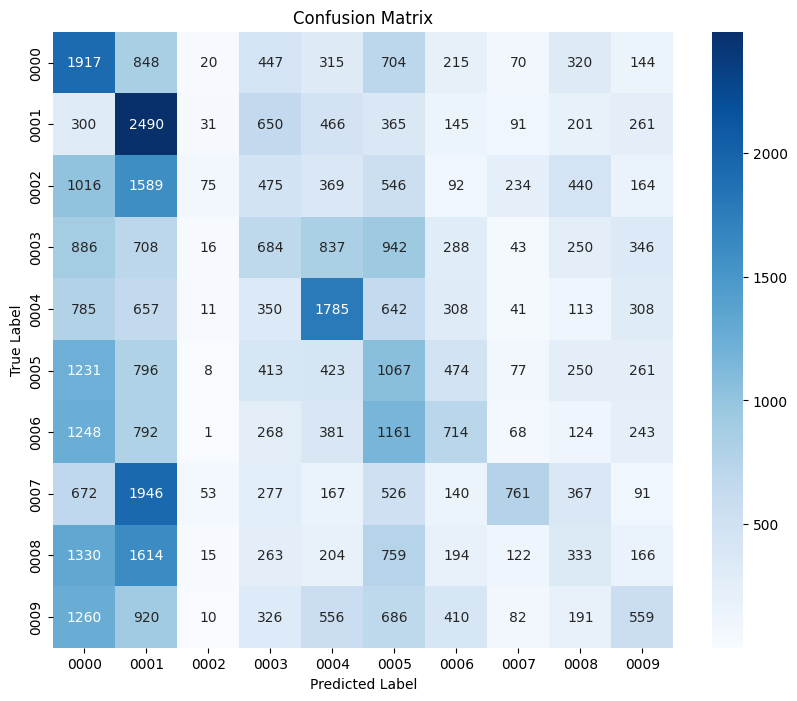

In [ ]:
# --- MAIN EXECUTION ---

# 1. Define Transforms
data_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 2. Load Resources
idx_to_class = load_label_map(LABEL_MAP_PATH)
model = get_model(MODEL_PATH, NUM_CLASSES, DEVICE)

if model is None or not idx_to_class:
    print("Stopping execution due to missing model or label map.")
else:
    # Lists to store results for metrics
    y_true = []
    y_pred = []

    print("\nStarting evaluation...")

    if os.path.exists(TEST_DIR):
        # Sort folders to ensure consistent order (0000, 0001...)
        folders = sorted([f for f in os.listdir(TEST_DIR) if os.path.isdir(os.path.join(TEST_DIR, f))])

        for class_folder_name in folders:
            # Check if folder name is in our label values (e.g. "0000")
            # Inverting map to check: val -> key
            if class_folder_name not in idx_to_class.values():
                continue

            class_path = os.path.join(TEST_DIR, class_folder_name)
            # print(f"Processing folder: {class_folder_name}...", end=" ")

            for img_file in os.listdir(class_path):
                if img_file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.pt')):
                    img_path = os.path.join(class_path, img_file)

                    # Predict
                    pred_idx = predict_image(img_path, model, data_transforms, DEVICE)

                    if pred_idx is not None:
                        pred_label_name = idx_to_class.get(pred_idx, "Unknown")

                        # Store Ground Truth and Prediction
                        y_true.append(class_folder_name)
                        y_pred.append(pred_label_name)

            # print("Done.") # Optional: keep output clean

        # --- 3. GENERATE METRICS & REPORT ---

        # Get unique class names sorted (0000 -> 0009)
        class_names = sorted(list(idx_to_class.values()))

        print("\n" + "="*60)
        print("CLASSIFICATION REPORT (Precision, Recall, F1)")
        print("="*60)

        # This function generates the table you asked for
        print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

        # --- 4. GENERATE CONFUSION MATRIX PLOT ---
        cm = confusion_matrix(y_true, y_pred, labels=class_names)

        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=class_names, yticklabels=class_names)
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.title('Confusion Matrix')
        plt.show()

    else:
        print(f"Test directory not found: {TEST_DIR}")

Loading model from: /content/drive/Shareddrives/Computer Vision/faces_model_checkpoints/resnet34_faces_best_32.pt


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)



Starting evaluation...

CLASSIFICATION REPORT (Precision, Recall, F1)
              precision    recall  f1-score   support

           0     0.1801    0.3834    0.2451      5000
           1     0.2015    0.4980    0.2869      5000
           2     0.3125    0.0150    0.0286      5000
           3     0.1647    0.1368    0.1495      5000
           4     0.3244    0.3570    0.3399      5000
           5     0.1442    0.2134    0.1721      5000
           6     0.2396    0.1428    0.1789      5000
           7     0.4789    0.1522    0.2310      5000
           8     0.1286    0.0666    0.0878      5000
           9     0.2198    0.1118    0.1482      5000

    accuracy                         0.2077     50000
   macro avg     0.2394    0.2077    0.1868     50000
weighted avg     0.2394    0.2077    0.1868     50000



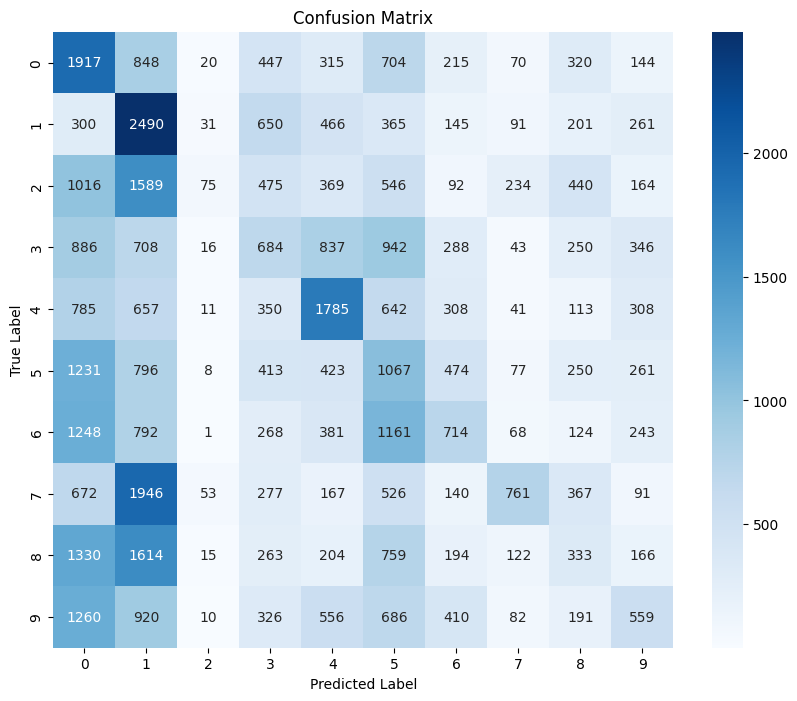

In [ ]:
import os
import torch
from torchvision import transforms
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# (假設前面 load_label_map, get_model, predict_image 等函式都已經定義好)

# --- MAIN EXECUTION ---

# 1. Define Transforms
data_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 2. Load Resources
idx_to_class = load_label_map(LABEL_MAP_PATH)
model = get_model(MODEL_PATH, NUM_CLASSES, DEVICE)

if model is None or not idx_to_class:
    print("Stopping execution due to missing model or label map.")
else:
    # Lists to store results for metrics
    y_true = []
    y_pred = []

    print("\nStarting evaluation...")

    if os.path.exists(TEST_DIR):
        # Sort folders to ensure consistent order (0000, 0001...)
        folders = sorted([f for f in os.listdir(TEST_DIR) if os.path.isdir(os.path.join(TEST_DIR, f))])

        for class_folder_name in folders:
            # Check if folder name is in our label values (e.g. "0000")
            if class_folder_name not in idx_to_class.values():
                continue

            class_path = os.path.join(TEST_DIR, class_folder_name)

            for img_file in os.listdir(class_path):
                if img_file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.pt')):
                    img_path = os.path.join(class_path, img_file)

                    # Predict
                    pred_idx = predict_image(img_path, model, data_transforms, DEVICE)

                    if pred_idx is not None:
                        pred_label_name = idx_to_class.get(pred_idx, "Unknown")

                        # Store Ground Truth and Prediction (原本的 0000 格式)
                        y_true.append(class_folder_name)
                        y_pred.append(pred_label_name)

        # ==========================================
        # ★★★ 修改重點：在這裡進行 Label 轉換 ★★★
        # ==========================================

        # 定義一個轉換函數：把 "0000" 轉成 int 再轉回 str -> "0"
        def simplify_label(label):
            try:
                return str(int(label))
            except:
                return label

        # 將原本的 list 進行轉換
        y_true_simple = [simplify_label(y) for y in y_true]
        y_pred_simple = [simplify_label(y) for y in y_pred]

        # 重新生成簡化後的 class names (確保排序是 0, 1, 2... 而不是 0, 1, 10)
        # 這裡我們從 idx_to_class 抓出來轉，確保完整性
        original_class_names = sorted(list(idx_to_class.values()))
        class_names_simple = sorted([simplify_label(name) for name in original_class_names], key=int)

        # --- 3. GENERATE METRICS & REPORT ---

        print("\n" + "="*60)
        print("CLASSIFICATION REPORT (Precision, Recall, F1)")
        print("="*60)

        # 使用轉換後的 y_true_simple, y_pred_simple 和 class_names_simple
        print(classification_report(y_true_simple, y_pred_simple, target_names=class_names_simple, digits=4))

        # --- 4. GENERATE CONFUSION MATRIX PLOT ---
        cm = confusion_matrix(y_true_simple, y_pred_simple, labels=class_names_simple)

        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=class_names_simple, yticklabels=class_names_simple)
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.title('Confusion Matrix')
        plt.show()

    else:
        print(f"Test directory not found: {TEST_DIR}")

Loading model from: /content/drive/Shareddrives/Computer Vision/faces_model_checkpoints/resnet34_faces_best_32.pt


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)



Starting evaluation...

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0     0.1801    0.3834    0.2451      5000
           1     0.2015    0.4980    0.2869      5000
           2     0.3125    0.0150    0.0286      5000
           3     0.1647    0.1368    0.1495      5000
           4     0.3244    0.3570    0.3399      5000
           5     0.1442    0.2134    0.1721      5000
           6     0.2396    0.1428    0.1789      5000
           7     0.4789    0.1522    0.2310      5000
           8     0.1286    0.0666    0.0878      5000
           9     0.2198    0.1118    0.1482      5000

    accuracy                         0.2077     50000
   macro avg     0.2394    0.2077    0.1868     50000
weighted avg     0.2394    0.2077    0.1868     50000


VISUALIZING ERRORS: GT='0002' but PRED='0001'
Found 1589 such images.


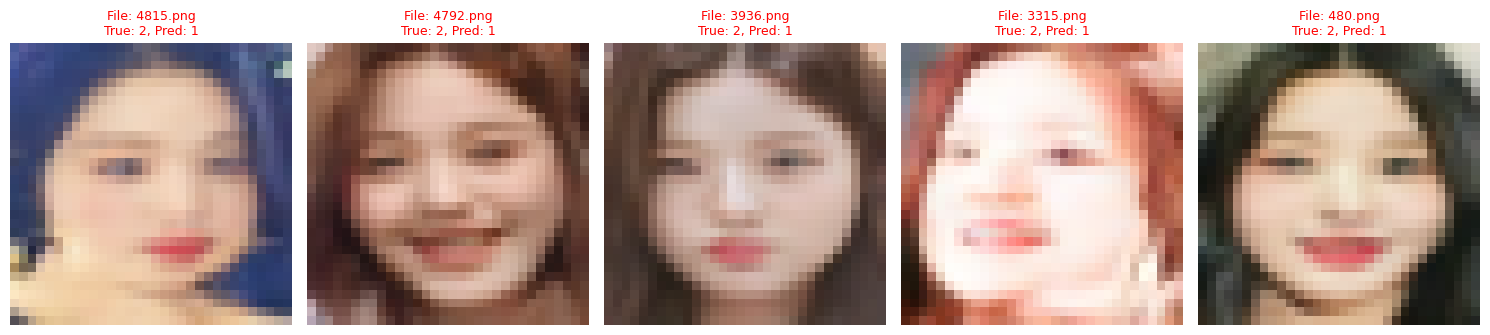

In [9]:
import os
import torch
from torchvision import transforms
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import matplotlib.image as mpimg # 用來讀圖
import seaborn as sns

# (假設前面 load_label_map, get_model, predict_image 等函式都已經定義好)

# --- MAIN EXECUTION ---

# 1. Define Transforms
data_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 2. Load Resources
idx_to_class = load_label_map(LABEL_MAP_PATH)
model = get_model(MODEL_PATH, NUM_CLASSES, DEVICE)

if model is None or not idx_to_class:
    print("Stopping execution due to missing model or label map.")
else:
    # Lists to store results for metrics
    y_true = []
    y_pred = []

    # ★★★ 新增：用來存 "2 被認成 1" 的圖片路徑 ★★★
    mistakes_2_as_1 = []

    print("\nStarting evaluation...")

    if os.path.exists(TEST_DIR):
        folders = sorted([f for f in os.listdir(TEST_DIR) if os.path.isdir(os.path.join(TEST_DIR, f))])

        for class_folder_name in folders:
            # Check if folder name is in our label values
            if class_folder_name not in idx_to_class.values():
                continue

            class_path = os.path.join(TEST_DIR, class_folder_name)

            for img_file in os.listdir(class_path):
                if img_file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.pt')):
                    img_path = os.path.join(class_path, img_file)

                    # Predict
                    pred_idx = predict_image(img_path, model, data_transforms, DEVICE)

                    if pred_idx is not None:
                        pred_label_name = idx_to_class.get(pred_idx, "Unknown")

                        # Store Ground Truth and Prediction
                        y_true.append(class_folder_name)
                        y_pred.append(pred_label_name)

                        # ==========================================
                        # ★★★ 修改重點：抓出特定的錯誤案例 ★★★
                        # ==========================================
                        # 真實標籤是 "0002" (Class 2)，但被預測為 "0001" (Class 1)
                        if class_folder_name == "0002" and pred_label_name == "0001":
                            mistakes_2_as_1.append(img_path)

        # --- LABEL SIMPLIFICATION ---
        def simplify_label(label):
            try:
                return str(int(label))
            except:
                return label

        y_true_simple = [simplify_label(y) for y in y_true]
        y_pred_simple = [simplify_label(y) for y in y_pred]

        original_class_names = sorted(list(idx_to_class.values()))
        class_names_simple = sorted([simplify_label(name) for name in original_class_names], key=int)

        # --- 3. GENERATE METRICS & REPORT ---
        print("\n" + "="*60)
        print("CLASSIFICATION REPORT")
        print("="*60)
        print(classification_report(y_true_simple, y_pred_simple, target_names=class_names_simple, digits=4))

        # --- 4. GENERATE CONFUSION MATRIX PLOT ---
        # (這裡保持原本的 Confusion Matrix 程式碼，省略以節省版面)
        # ... plt.show() ...

        # ==========================================
        # ★★★ 新增：畫出 "Class 2 -> Class 1" 的錯誤圖片 ★★★
        # ==========================================
        print("\n" + "="*60)
        print(f"VISUALIZING ERRORS: GT='0002' but PRED='0001'")
        print(f"Found {len(mistakes_2_as_1)} such images.")
        print("="*60)

        if len(mistakes_2_as_1) > 0:
            # 限制顯示數量，避免太多圖當機 (例如最多顯示 5 張)
            num_to_show = min(5, len(mistakes_2_as_1))

            plt.figure(figsize=(15, 5))
            for i in range(num_to_show):
                img_path = mistakes_2_as_1[i]

                # 讀取圖片
                img = mpimg.imread(img_path)

                plt.subplot(1, num_to_show, i + 1)
                plt.imshow(img)
                plt.axis('off')

                # 顯示檔名方便除錯
                file_name = os.path.basename(img_path)
                plt.title(f"File: {file_name}\nTrue: 2, Pred: 1", fontsize=9, color='red')

            plt.tight_layout()
            plt.show()
        else:
            print("Great! No instances found where Class 2 was misclassified as Class 1.")

    else:
        print(f"Test directory not found: {TEST_DIR}")